**NOTICE:**
The U.S. Army Corps of Engineers, Risk Management Center (USACE-RMC) makes no guarantees about the results, or appropriateness of outputs, obtained from Numerics.


# 00. Getting Started with RMC-BestFit in Python
Welcome! This notebook will guide you through setting up and using the USACE-RMC BestFit library in Python via PythonNet.

## What You Will Learn
- What the BestFit library provoides and where it fits in the workflow
- How to obtain or load `Numerics.dll` and `RMC.BestFit.dll`
- How to load the correct .NET runtime and add the DLL reference from Python
- Import and use `RMC.BestFit` namespaces directly
- Build a BestFit `DataFrame` with `ExactData`
- Build a BestFit `UnivariateDistribution` model
- Run BestFit `MaximumLikelihood` and `BayesianAnalysis`

## Virtual Python Environment
Before we get to BestFit, we need to ensure Python is up and running on your device and in these notebooks. In the top right hand corner of this notebook click on the **"Select Kernel"** button. A Python environment should be available for you to chose from, assuming you've downloaded Python. If you have Python on your computer, but cannot find a Python kernel to select, don't worry we have a solution. We will create and virtual Python environment just for this library to work with.

This virtual Python environment will give this library its own copy of Python, its own set of tools and libraries, and keeping it isolated from other projects. Before we start, please ensure you have the new version of Python installed locally on your device.

1. Open a new terminal and make sure it is pointing to your project folder (you should see the folder path in the prompt)
2. To create the virtual environment, run one of the commands  below:        
   ```bash 
   # Mac/Linux
   python3 -m venv .venv
   # Windows
   python -m venv .venv
   ```
   This will create the .venv folder in your project. Double check that you can see this folder in the file explorer.
3. Now we will activate the virtual environment:
   ```bash
   # Mac/Linux
   source .venv/bin/activate
   # Windows (Command Prompt)
   .venv\Scripts\activate.bat
   # Windows (PowerShell)
   .venv\Scripts\Activate.ps1
   ```
   You should now see `(.venv)` appear at the start of the terminal prompt. This means it's active!
4. Install ipykernel. This is what allows Jupyter to see your virtual environment as a kernel. With the `.venv` active run:
   ```bash
   pip install ipykernel
   ```
   Then register it: 
   ```bash
   # Mac/Linux
   python3 -m ipykernel install --user --name=.venv --display-name "Python (.venv)"
   # Windows
   python -m ipykernel install --user --name=.venv --display-name "Python (.venv)"
   ```
5. Now you should be able to select this virtual environment as a kernel. Click on the **"Select Kernel"** in the top right. Chose Python environments and select Python(.venv), the one you just created! If it doesn't show up right away, try reloading your window.
6. Open the command palette (Ctrl+Shift+P or Cmd+Shift+P) and find **"Python:Select Interpreter"**. Chose the .venv option to tell VS code to always use this interpreter going forward.

Now we have ensured that we can use and run Python in there Jupyter notebooks. Time to get down to business in BestFit!

## What is BestFit?
RMC-BestFit is a state-of-the-art Bayesian estimation and fitting software developed collaboratively by the U.S. Army Corps of Engineers' Risk Management Center (RMC) and Engineer Research and Development Center's Coastal and Hydraulics Laboratory (CHL). Tailored to expedite flood hazard assessments for the Flood Risk Management, Planning, and Dam and Levee Safety communities, the software employs a Bayesian framework to integrate a variety of data sources, including historical records, paleoflood evidence, regional data, rainfall-runoff models, and expert judgment. This intuitive application provides a comprehensive environment for distribution fitting and Bayesian estimation. It includes:
- Various data import methods
- Advanced hypothesis testing
- Probability distributions
- Nonstationary flood frequency analysis
- Complex modeling techniques
- Dependency modeling

## Obtaining BestFit from the USACE-RMC GitHub Page
There are 2 recommend ways to obtain BestFit.

### Option 1: Download the Repository Directly

1. Visit the [USACE-RMC/RMC-BestFit GitHub repository](https://github.com/USACE-RMC/RMC-BestFit)
2. Click the green **"Code"** button and select **"Download ZIP"**
3. Extract the ZIP file to a location on your computer
4. Build the solution (requires Visual Studio or .NET SDK):
   ```bash
   cd RMC-BestFit
   dotnet build RMC-BestFit.sln --configuration Release
   ```
5. The compiled `RMC.BestFit.dll` will be in `RMC-BestFit/Libraries/Release/RMC.BestFit.dll` (or similar)

### Option 2: Clone with Git (Recommended for Auto-Updates)

This approach allows you to easily pull the latest changes without re-downloading everything.

1. Install Git (if not already installed): [git-scm.com](https://git-scm.com/)
2. Clone the repository:
   ```bash
   git clone https://github.com/USACE-RMC/RMC-BestFit
   cd RMC-BestFit
   ```
3. Build the DLL:
   ```bash
   dotnet build RMC-BestFit.sln --configuration Release
   ```
4. Update to latest version anytime:
   ```bash
   cd RMC-BestFit  # Navigate to the cloned directory
   git pull origin main  # Pull latest changes
   dotnet build RMC-BestFit.sln --configuration Release  # Rebuild

This demo also uses methods from RMC-Numerics. When downloading RMC-BestFit it automatically comes with the Numerics.dll inside, so you should be good to go. Once you find the RMC.BestFit.dll, your Numerics.dll will be in the same folder. To learn more about using Numerics in Python check out [Numerics-Python-Examples](https://github.com/USACE-RMC/Numerics-Python-Examples). We recommend completing the Numerics Python demo before this one, but by no means is it required.

## Prerequisites
Before running this notebook, ensure you have:
1. .NET Runtime (6.0+ or .NET Framework 4.8.1 on Windows)
2. Python 3.8+
3. Required packages (install via pip). See ```notebook-requirements.txt``` for the full list of external python packages you need to install to run all of the notebooks.

Now that you have Numerics up and running the core workflow is: 
1. Load the .NET runtime.
2. Add the BestFit and Numerics DLL references.
3. Import namespaces and use Numerics as if it were a native Python library.

## Step 1: Load the .NET Runtime.
**CRITICAL:** You must load the .NET runtime before importing `clr`. This is the most common setup mistake.

Runtime selection:
- Use `pythonnet.load("coreclr")` for .NET 6/7/8.
- Use `pythonnet.load("netfx")` only for .NET Framework (Windows-only).

If you're not sure which you have installed, check the Numerics build output folder (e.g., `net8.0` indicates CoreCLR).


In [3]:
import pythonnet

# Use netfx for this Beta-3 build (Windows/.NET Framework).
# Switch to coreclr if your BestFit build targets .NET 6+.
pythonnet.load("netfx")

print("✓ .NET runtime loaded")

✓ .NET runtime loaded


## Step 2: Import clr and Load DLLs

Now we can import the CLR bridge and load the BestFit and Numerics assemblies. A lot of BestFit methods are built off of the Numerics library and require Numerics objects to be passed to them. When you download BestFit, it should come with both the RMC.BestFit.dll and Numerics.dll under the Libraries folder. We are using the latest version of BestFit Version 2.0 (Beta-3).

This repository also comes with two built in helper functions to find your respective DLLs, `resolve_bestfit-dll()` and `resolve_numerics_dll()`.

How DLL helpers work:
- `resolve_bestfit_dll()` checks `RMC_BESTFIT_DLL`, a global variable users can set with the direct path to the DLL, first, then known local fallback paths, and returns the first existing file.
- `resolve_numerics_dll()` does the same for `RMC_NUMERICS_DLL`.
- If no valid file is found, each function raises a clear `FileNotFoundError` so you can fix pathing immediately.

In [4]:
import clr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from helper_functions import resolve_bestfit_dll, resolve_numerics_dll, convert_to_donet_array

clr.AddReference(str(resolve_numerics_dll()))
clr.AddReference(str(resolve_bestfit_dll()))

print("✓ Numerics loaded from:", resolve_numerics_dll())
print("✓ BestFit loaded from:", resolve_bestfit_dll())

✓ Numerics loaded from: C:\GIT\RMC-BestFit Version 2.0 (Beta-3)\Release\Libraries\Numerics.dll
✓ BestFit loaded from: C:\GIT\RMC-BestFit Version 2.0 (Beta-3)\Release\Libraries\RMC.BestFit.dll


## Step 3: Import Namespaces
Now we can import classes from Numerics and BestFit just like any other Python module. Be sure to check how the namespaces are organized within each library. Below we import the namespaces needed for a handful of basic examples.

In [5]:
from Numerics.Distributions import UnivariateDistributionType, Gumbel, Normal
from RMC.BestFit import DataFrame, ExactData
from RMC.BestFit.Model import UnivariateDistribution
from RMC.BestFit.Estimation import MaximumLikelihood
from System import Array, Double

print("✓ Imported namespaces successfully")

✓ Imported namespaces successfully


## Looking At Assemblies and Namespaces

In [6]:
import sys
from System.Reflection import Assembly

assembly = Assembly.LoadFrom(str(resolve_bestfit_dll()))
# List all namespaces
namespaces = set()
for typ in assembly.GetTypes():
    ns = typ.Namespace
    if ns and ('BestFit' in ns or 'RMC' in ns):  # Filter relevant
        namespaces.add(ns)

print("Relevant Namespaces:")
for ns in sorted(namespaces):
    print(f"- {ns}")

# List classes in a specific namespace (e.g., RMC.BestFit)
target_ns = 'RMC.BestFit'  # Adjust as needed
classes = [t.FullName for t in assembly.GetTypes() if t.Namespace == target_ns]
print("\nClasses in RMC.BestFit:")
for cls in sorted(classes):
    print(f"- {cls}")


def type_kind(t):
    if t.IsEnum:
        return "Enum"
    if t.IsInterface:
        return "Interface"
    if t.IsClass and t.IsAbstract and t.IsSealed:
        return "Static Class"
    if t.IsClass and t.IsAbstract:
        return "Abstract Class"
    if t.IsClass:
        return "Class"
    if t.IsValueType:
        return "Struct"
    return "Other"

types = assembly.GetTypes()

# 1) Print any type whose name suggests fitting analysis
keywords = ["FittingAnalysis", "FitAnalysis", "Fitting", "Fit"]
candidates = [
    t for t in types
    if t.Name is not None and any(k in t.Name for k in keywords)
]

print("=== Possible fitting-analysis types ===")
for t in sorted(candidates, key=lambda x: x.FullName):
    print(f"{t.FullName} [{type_kind(t)}]")

# 2) If you want to restrict to RMC.BestFit namespaces:
print("\n=== Within RMC.BestFit* only ===")
for t in sorted(types, key=lambda x: x.FullName):
    ns = t.Namespace or ""
    if ns.startswith("RMC.BestFit") and any(k in t.Name for k in keywords):
        print(f"{t.FullName} [{type_kind(t)}]")

Relevant Namespaces:
- RMC.BestFit
- RMC.BestFit.Estimation
- RMC.BestFit.Model
- RMC.BestFit.Model.SpatialExtremes
- RMC.BestFit.Properties

Classes in RMC.BestFit:
- RMC.BestFit.BayesianAnalysis
- RMC.BestFit.BayesianAnalysis+<>c
- RMC.BestFit.BayesianAnalysis+<>c__DisplayClass148_0
- RMC.BestFit.BayesianAnalysis+<>c__DisplayClass151_0
- RMC.BestFit.BayesianAnalysis+<RunAsync>d__148
- RMC.BestFit.BayesianAnalysis+PointEstimateType
- RMC.BestFit.BayesianAnalysis+SamplerType
- RMC.BestFit.BivariateAnalysis
- RMC.BestFit.BivariateAnalysis+<>c
- RMC.BestFit.BivariateAnalysis+<>c__DisplayClass117_0
- RMC.BestFit.BivariateAnalysis+<>c__DisplayClass117_1
- RMC.BestFit.BivariateAnalysis+<CreateFrequencyAnalysisResultsAsync>d__117
- RMC.BestFit.BivariateAnalysis+<RunAsync>d__114
- RMC.BestFit.BivariateAnalysis+<UpdatePointEstimateResultsAsync>d__116
- RMC.BestFit.BivariateAnalysisCollection
- RMC.BestFit.CoincidentFrequencyAnalysis
- RMC.BestFit.CompositeAnalysis
- RMC.BestFit.CompositeAnalys

## Working with .NET Arrays
Many BestFit andNumerics methods require .NET arrays instead of Python lists. Here's how we can convert between them. There are also helper functions in `notebooks/helper_functions.py`: `convert_to_dotnet_array(pythonList)`. Through this notebook we will continue to cover this conversion. When creating your own BestFit projects in Python, if a method fails that first thing you should do is double check that you are passing the right type of data to it.

In [7]:
# Python list to .NET Array[Double]
python_data = [10.5, 20.3, 15.7, 18.9, 22.1]
dotnet_array = Array[Double](python_data)

print(f"Python list: {python_data}")
# Accessing .NET array elements since Python doesn't know how to print a .NET array directly
print(f".NET array: {[dotnet_array[i] for i in range(dotnet_array.Length)]}")

# .NET array back to Python list
back_to_python = [dotnet_array[i] for i in range(dotnet_array.Length)]
# Or more concisely:
back_to_python = list(dotnet_array)

print(f"Converted back: {back_to_python}")

Python list: [10.5, 20.3, 15.7, 18.9, 22.1]
.NET array: [10.5, 20.3, 15.7, 18.9, 22.1]
Converted back: [10.5, 20.3, 15.7, 18.9, 22.1]


## Example 1: Normal Distribution
We construct a `Normal` distribution, evaluate `PDF`, `CDF`, and `InverseCDF`, and confirm plotting works. This example largely uses methods only from the Numerics library, but it a good introduction to using RMC libraries in Python.

What to look for:
- `Mean` and `StandardDeviation` should match the constructor values.
- `CDF(120)` should be larger than 0.5 because 120 is above the mean (100).
- The PDF should peak near the mean.

Mean=100.000, Std=15.000
P(X<120)=0.9088
Q(0.90)=119.2233


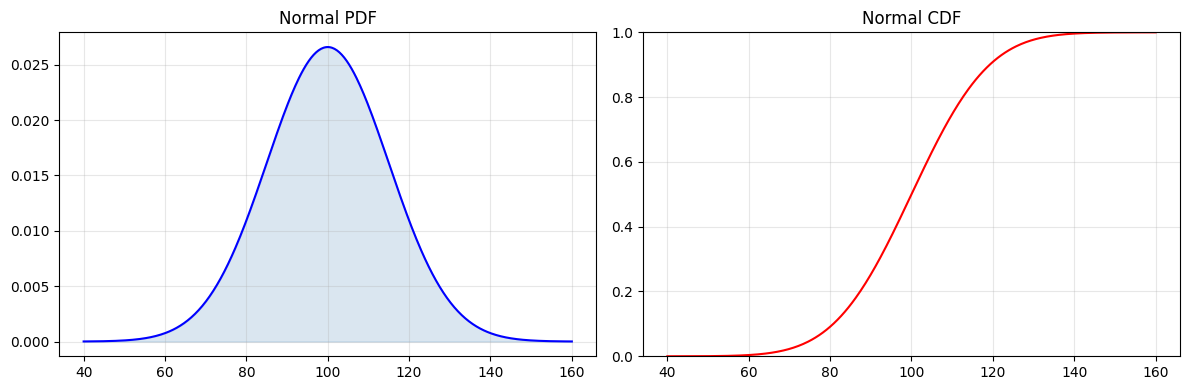

In [8]:
# Create a Normal distribution with mean=100 and std=15, then compute PDF/CDF values for a range of x
dist = Normal(100.0, 15.0)
x = np.linspace(40, 160, 400)
pdf = np.array([float(dist.PDF(float(v))) for v in x])
cdf = np.array([float(dist.CDF(float(v))) for v in x])

print(f"Mean={float(dist.Mean):.3f}, Std={float(dist.StandardDeviation):.3f}")
print(f"P(X<120)={float(dist.CDF(120.0)):.4f}")
print(f"Q(0.90)={float(dist.InverseCDF(0.90)):.4f}")

# Plot the PDF and CDF
fig, ax = plt.subplots(1,2, figsize=(12,4))

ax[0].plot(x, pdf, 'b-')
ax[0].fill_between(x, pdf, color='steelblue', alpha=0.2)
ax[0].set_title('Normal PDF')
ax[0].grid(alpha=0.3)

ax[1].plot(x, cdf, 'r-')
ax[1].set_title('Normal CDF')
ax[1].set_ylim(0,1)
ax[1].grid(alpha=0.3)

plt.tight_layout()

## Example 2: Build a BestFit DataFrame
This example shows how to move from raw values into a BestFit `DataFrame`.

Why this matters:
- `DataFrame` is the core input object used by BestFit analyses.
- It stores observations with metadata (index/year, type, plotting position).
- The same structure later supports exact, uncertain, interval, and threshold data types.

When working with BestFit and Numerics methods, we must pass them .NET arrays and data types. We must be careful when defining our variables and passing them back and forth. Below we first define our synthetic data in Python. Then we pass it to the BestFit DataFrame, converting it to ints and floats. To print our results at the end we have to convert the .NET DataFrame back to a Python DataFrame to access the elements. It is a little confusing and can seem redundant at first, but as we continue with this demo, we will get better at switching between types and cut out some unnecessary middle steps.

The next code cell (GEV workflow setup) also performs this DataFrame construction step.

## Basic Example 3: Gumbel Flood-Frequency Workflow
Now we do a small end-to-end Gumbel workflow with a dataset that is more representative of block maxima:

1. Annual-maximum style values (stationary-ish center, right-skewed upper tail).
2. Build BestFit `DataFrame` and Gumbel model.
3. Run MLE and graph the fitted distribution.

In [9]:
# Annual-maximum style sample tuned to be more Gumbel-like
annual_peaks = [
    7680, 8010, 8290, 8570, 8840,
    9130, 9410, 9680, 9950, 10240,
    10510, 10820, 11140, 11490, 11860,
    12250, 12690, 13160, 13680, 14260,
    14910, 15650, 16510, 17500, 18650,
]

df = DataFrame()
start_year = 1999

for i, value in enumerate(annual_peaks):
    df.ExactSeries.Add(ExactData(start_year + i, float(value)))

df.PlottingParameter = 0.0  # Weibull plotting positions
df.CalculatePlottingPositions()

print("BestFit DataFrame summary")
print(f"- Exact observations: {df.ExactSeries.Count}")
print(f"- Total record length: {df.TotalRecordLength()}")
print(f"- Plotting parameter: {df.PlottingParameter}")

print("First 5 records")
for i in range(min(5, df.ExactSeries.Count)):
    rec = df.ExactSeries[i]
    print(f"  index={rec.Index}, value={rec.Value:.1f}, p={rec.PlottingPosition:.4f}")


BestFit DataFrame summary
- Exact observations: 25
- Total record length: 25
- Plotting parameter: 0.0
First 5 records
  index=1999, value=7680.0, p=0.9615
  index=2000, value=8010.0, p=0.9231
  index=2001, value=8290.0, p=0.8846
  index=2002, value=8570.0, p=0.8462
  index=2003, value=8840.0, p=0.8077


### Build a BestFit Univariate Model
Create a BestFit univariate model. In RMC-BestFit, a model is any mathematical representation of a physical process that can be fitted to data. Models define the relationship between parameters and observations, specify prior distributions for Bayesian inference, and compute likelihood functions that measure how well parameter values explain the data.

We will chose to use the Gumbel Distribution, a pre built model commonly used in flood frequency analysis.

In [10]:
# This is a UnivariateDistribution is a BestFit method -- there is a similar one implemented in Numerics
# UnivariateDistributionType is a Numerics method, used by BestFit
# Be sure you call the right methods from the right libraries and namespaces as there is a lot of overlap
# One wrong import can cause a lot of confusion and trouble!
gumbel_model = UnivariateDistribution(df, UnivariateDistributionType.Gumbel)

print("BestFit model summary")
print(f"- Distribution type: {gumbel_model.Distribution.Type}")
print(f"- Display name: {gumbel_model.Distribution.DisplayName}")
print(f"- Number of parameters: {gumbel_model.NumberOfParameters}")


BestFit model summary
- Distribution type: Gumbel
- Display name: Gumbel (EVI)
- Number of parameters: 2


Fitted parameters
- location: 11795.2
- scale: 2587.493302


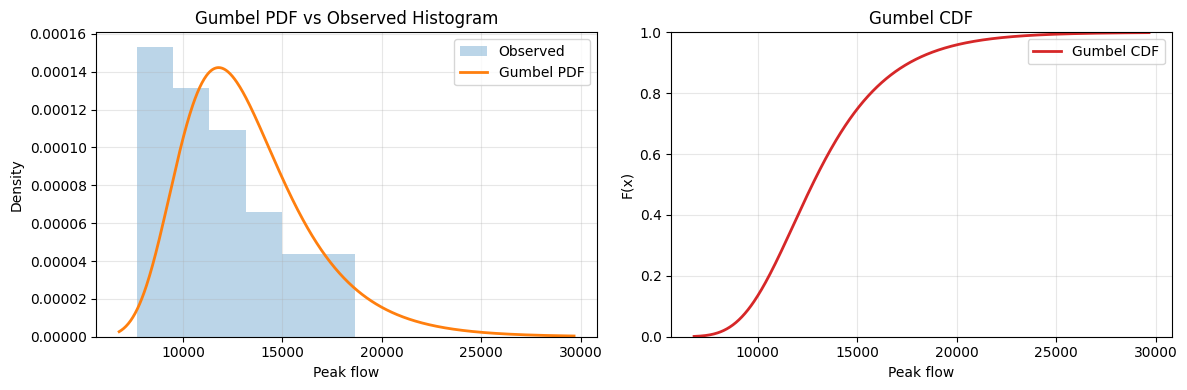

In [11]:
loc0 = float(np.mean(annual_peaks))
scale0 = float(max(1e-6, 0.8 * np.std(annual_peaks, ddof=1)))
xmin = float(np.min(annual_peaks))
xmax = float(np.max(annual_peaks))
span = max(1.0, xmax - xmin)

# Explicit initialization and finite bounds prevent degenerate optimizer states.
gumbel_model.Parameters[0].Value = loc0
gumbel_model.Parameters[0].LowerBound = xmin - 2.0 * span
gumbel_model.Parameters[0].UpperBound = xmax + 2.0 * span

gumbel_model.Parameters[1].Value = scale0
gumbel_model.Parameters[1].LowerBound = 1e-6
gumbel_model.Parameters[1].UpperBound = 10.0 * span

# Estimate parameters using BestFit MLE
mle = MaximumLikelihood(gumbel_model)
mle.Estimate()

mle_params = np.array([float(v) for v in mle.BestParameterSet.Values], dtype=float)
loc = mle_params[0]
scale = mle_params[1]

gumbel_model.SetParameterValues(convert_to_donet_array([loc, scale]))

# Use the fitted BestFit distribution directly for plotting.
gumbel_fit = gumbel_model.Distribution

print("Fitted parameters")
print("- location:", round(loc, 4))
print("- scale:", round(scale, 6))

# Plot fitted PDF/CDF
x_low = float(gumbel_fit.InverseCDF(0.001))
x_high = float(gumbel_fit.InverseCDF(0.999))
x = np.linspace(x_low, x_high, 600)
pdf = np.array([float(gumbel_fit.PDF(float(v))) for v in x])
cdf = np.array([float(gumbel_fit.CDF(float(v))) for v in x])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(annual_peaks, bins="auto", density=True, alpha=0.3, label="Observed")
ax[0].plot(x, pdf, lw=2, label="Gumbel PDF")
ax[0].set_title("Gumbel PDF vs Observed Histogram")
ax[0].set_xlabel("Peak flow")
ax[0].set_ylabel("Density")
ax[0].grid(alpha=0.3)
ax[0].legend()

ax[1].plot(x, cdf, lw=2, color="tab:red", label="Gumbel CDF")
ax[1].set_title("Gumbel CDF")
ax[1].set_xlabel("Peak flow")
ax[1].set_ylabel("F(x)")
ax[1].set_ylim(0, 1)
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()


Plotting-position orientation used: exceedance
Gumbel quick-check quantiles
- Q2: 12743.55
- Q10: 17618.01
- Q50: 21891.44
- Q100: 23698.06


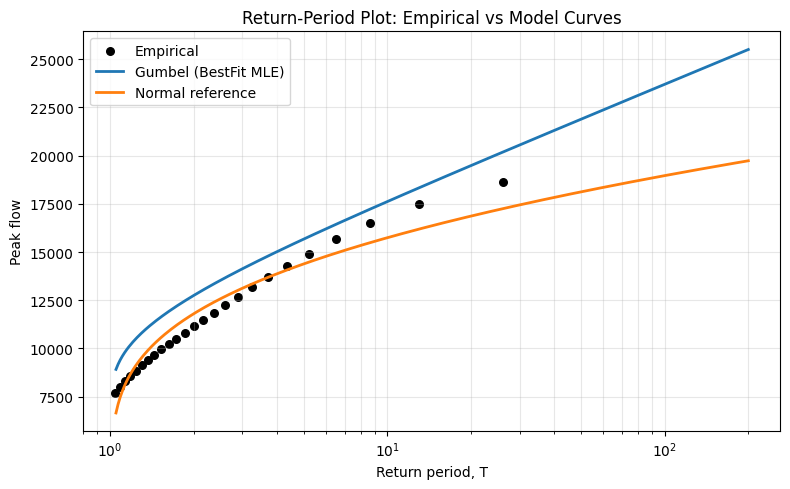

Exception in callback BaseAsyncIOLoop._handle_events()
handle: <Handle BaseAsyncIOLoop._handle_events()>
Traceback (most recent call last):
  File "c:\Users\q0rmcssn\AppData\Local\Programs\Python\Python313\Lib\asyncio\events.py", line 89, in _run
    self._context.run(self._callback, *self._args)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\q0rmcssn\AppData\Local\Programs\Python\Python313\Lib\site-packages\tornado\platform\asyncio.py", line 208, in _handle_events
    handler_func(fileobj, events)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "c:\Users\q0rmcssn\AppData\Local\Programs\Python\Python313\Lib\site-packages\zmq\eventloop\zmqstream.py", line 600, in _handle_events
    self._handle_recv()
    ~~~~~~~~~~~~~~~~~^^
  File "c:\Users\q0rmcssn\AppData\Local\Programs\Python\Python313\Lib\site-packages\zmq\eventloop\zmqstream.py", line 629, in _handle_recv
    self._run_callback(callback, msg)
    ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^
  File "c:\Users\q0rmcssn\AppData\Loc

In [12]:
# Build empirical return-period points from BestFit DataFrame outputs.
# We already asked BestFit to compute plotting positions (df.CalculatePlottingPositions),
# so this section maps those positions to exceedance probabilities and return periods.
vals = [float(df.ExactSeries[i].Value) for i in range(df.ExactSeries.Count)]
p_plot = [float(df.ExactSeries[i].PlottingPosition) for i in range(df.ExactSeries.Count)]

# BestFit plotting positions can be stored as either exceedance or non-exceedance orientation
# depending on context; detect orientation from value-probability correlation.
corr = float(np.corrcoef(np.array(vals, dtype=float), np.array(p_plot, dtype=float))[0, 1])
if corr < 0:
    p_exceed = [min(max(p, 1e-9), 1 - 1e-9) for p in p_plot]
    orientation = "exceedance"
else:
    p_exceed = [min(max(1.0 - p, 1e-9), 1 - 1e-9) for p in p_plot]
    orientation = "non-exceedance"

# Convert to return period T = 1 / p_exceed and sort for plotting.
pairs = sorted([(1.0 / p, v) for p, v in zip(p_exceed, vals)], key=lambda t: t[0])
T_emp = np.array([t for t, _ in pairs], dtype=float)
vals_emp = np.array([v for _, v in pairs], dtype=float)

# Model curves from Numerics distribution objects (already parameterized from BestFit MLE output).
T_grid = np.logspace(np.log10(1.05), np.log10(200), 300)
F_grid = 1.0 - 1.0 / T_grid

q_gumbel = np.array([float(gumbel_fit.InverseCDF(float(np.clip(f, 1e-6, 1 - 1e-6)))) for f in F_grid])
normal_curve = Normal(float(np.mean(annual_peaks)), max(1e-6, float(np.std(annual_peaks, ddof=1))))
q_norm = np.array([float(normal_curve.InverseCDF(float(np.clip(f, 1e-6, 1 - 1e-6)))) for f in F_grid])

plt.figure(figsize=(8, 5))
plt.scatter(T_emp, vals_emp, s=30, c="black", label="Empirical")
plt.plot(T_grid, q_gumbel, lw=2, label="Gumbel (BestFit MLE)")
plt.plot(T_grid, q_norm, lw=2, label="Normal reference")
plt.xscale("log")
plt.xlabel("Return period, T")
plt.ylabel("Peak flow")
plt.title("Return-Period Plot: Empirical vs Model Curves")
plt.grid(alpha=0.3, which="both")
plt.legend()
plt.tight_layout()

print(f"Plotting-position orientation used: {orientation}")
print("Gumbel quick-check quantiles")
for t in [2, 10, 50, 100]:
    f = 1.0 - 1.0 / t
    print(f"- Q{t}: {float(gumbel_fit.InverseCDF(float(f))):.2f}")


## Common Problems and Solutions
### 1. Runtime Not Loaded Error
Make sure you load the runtime BEFORE importing clr.

```python
# X WRONG - will fail
import clr
import pythonnet
pythonnet.load("netfx")

# ✓ CORRECT - load runtime FIRST
import pythonnet
pythonnet.load("netfx")
import clr
```

### 2. DLL Not Found
Verify the path in `dll_path` is correct and points to a dll that exists. If no dll exists, be sure that you have built the BestFit and Numerics solution.

### 3. Loading DLL More Than Once
When running multiple files at once, if they all load the DLLs with ```clr.AddReference(str(dll_path))``` it may fail with an error that they have  already been loaded. If this happens, add the statement below to check the assemblies and only load BestFit or Numerics if it is not already loaded. The code below doesn't output anything, but you'll know it worked if it runs without the failure error of loading multiple DLLS. This error shouldn't happened within these notebooks because they all have separate kernels. It would happen if you were trying to run multiple Python files all at once where each one loads the same DLL. In each of these files you would replace how you were originally loading the DLL with the chunk below.

```python
# Needed to access the assemblies
from System import AppDomain

assemblies = AppDomain.CurrentDomain.GetAssemblies()
assembly_names = [assembly.GetName().Name for assembly in assemblies]
if 'Numerics' not in assembly_names:
    clr.AddReference(str(dll_path))
```
The same chunk works if you replace 'Numerics' with 'RMC.BestFit'.
Better safe than sorry!

### 4. Array Type Mismatch
Check that you're using .NET arrays where required.

```python
# X WRONG - Python list
data = [1, 2, 3]
dist.LogLikelihood(data)  # Error!

# ✓ CORRECT - .NET array
data = Array[Double]([1, 2, 3])
dist.LogLikelihood(data)  # Works!
```

### Accessing .NET Properties
```python
# X WRONG - trying to call a property
mean_value = dist.Mean()  # Error!

# ✓ CORRECT - properties don't use parentheses
mean_value = dist.Mean
```
## Summary
Congratulations! You've finished the first notebook in this demo! You are well on your way to mastering BestFit in Python.

You've learned:     
$\checkmark$ Locating or building the RMC.BestFit.dll and Numerics.dll      
$\checkmark$ Loading the correct .NET run time      
$\checkmark$ Building a basic normal distribution example       
$\checkmark$ Using BestFit's DataFrame method       
$\checkmark$ How to build and use a basic BestFit Model     
$\checkmark$ How to fix common troubleshooting steps        

## Exercise
1. Change runtime load from `netfx` to `coreclr` in a .NET 6 build environment.
2. Replace synthetic peaks with a real gauge CSV.
3. Add one more distribution and compare its CDF to Normal.